# Training with many subsets

Next, we will take our method or constructing many subset and train a model with this more complicated data! This is a lot more interesting the datasets we previosuly trained on.

In [1]:
%load_ext autoreload
%autoreload 2

import os
import torch
os.environ['TORCH'] = torch.__version__
print(torch.__version__)
# Choose device (cuda if available, else cpu)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Selected device:", device)

2.9.0+cu128
Selected device: cuda


# Load Data

In [2]:
## Load the colmap data
import pycolmap
import pathlib
import utils.subset
import random
import utils.loaders

# Load the Colmap data into a torch dataset
model_path = pathlib.Path('./output/01_nerf/02_lego_large/1762043798762/0')
reconstruction = pycolmap.Reconstruction(model_path)

In [4]:
# Define the directory where our source images are from
image_dir = pathlib.Path('data', '01_nerf', '02_lego_large')

random.seed(42) # for reproducibility

graph_a_list = []
graph_b_list = []
labels = []
for i in range(100):
    # Create a random subset using distance based heuristic
    a_ids, b_ids = utils.subset.create_image_subsets_from_distance(reconstruction, 15, random_captains=True)
    # Create a PyG graph Dataset for each subset
    graph_a = utils.loaders.load_reconstruction_to_graph(reconstruction, image_dir, a_ids)
    graph_b = utils.loaders.load_reconstruction_to_graph(reconstruction, image_dir, b_ids)
    # Randomly perturb the transforms. We uniformly sample 3 values from the range [-10.0, 10.0]
    perturbation = torch.empty(3).uniform_(-10.0,10.0)
    graph_b.x[:,:3] = graph_b.x[:,:3] + perturbation
    # TODO perturb graph_a too with a different value, and then add perturbations to derive label
    graph_a_list.append(graph_a)
    graph_b_list.append(graph_b)
    labels.append(perturbation)

In [5]:
from utils.loaders import GraphPairDataset

# Create the Dataset!
#TODO can I save these to disk?
dataset = GraphPairDataset(graph_a_list, graph_b_list, labels)
dataset

GraphPairDataset(100)

# Aside: Example of saving and loading this precomputed dataset

In [103]:
dataset.save("data/data.pt")

In [5]:
from utils.loaders import GraphPairDataset

dataset = GraphPairDataset.load("data/data.pt")

# Training Loop

## Construct dataloaders

In [6]:
from torch_geometric.loader import DataLoader
from torch.utils.data import random_split

# Split our dataset based on 80-20 training-validation split
dataset_size = len(dataset)
train_size = int(dataset_size * 0.8)
val_size = dataset_size - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# And we create a distinct DataLoader for each dataset train and val
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)

## Train

In [7]:
import numpy as np
from models import SiameseGCN_v1
from tqdm import tqdm

torch.manual_seed(43)
random.seed(43)

# Define model
# To get our number of node features, let's check the first Data and the first graph_a
num_node_features = dataset.g_list_1[0].num_features
model = SiameseGCN_v1(num_node_features)
model.to(device)

SiameseGCN_v1(
  (sisterA): GraphEmbeddingGCN_v1(
    (conv1): GCNConv(30, 4)
    (conv2): GCNConv(4, 4)
    (linear): Linear(in_features=4, out_features=4, bias=True)
  )
  (sisterB): GraphEmbeddingGCN_v1(
    (conv1): GCNConv(30, 4)
    (conv2): GCNConv(4, 4)
    (linear): Linear(in_features=4, out_features=4, bias=True)
  )
  (linear1): Linear(in_features=8, out_features=8, bias=True)
  (linear2): Linear(in_features=8, out_features=8, bias=True)
  (mlp): Sequential(
    (0): Linear(in_features=8, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=3, bias=True)
  )
)

In [8]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.8)
criterion = torch.nn.MSELoss()

num_epochs = 800

# Keep track of loss
epoch_losses_train = []
epoch_losses_val = np.full(num_epochs, np.nan)  # one slot per epoch
with tqdm(range(num_epochs),desc=f"Training progress") as pbar:
    for epoch in pbar:
        model.train()
        train_loss = 0.0
        for batch in train_loader:
            # Move data to the GPU
            graph_a_batch = batch[0].to(device)
            graph_b_batch = batch[1].to(device)
            label_batch   = batch[2].to(device)
            optimizer.zero_grad()
            out = model(graph_a_batch, graph_b_batch)
            loss = criterion(out, label_batch)
            # Compute gradient
            loss.backward()
            # update the weights
            optimizer.step()
            train_loss += loss.item()
        avg_loss = train_loss / len(train_loader)
        epoch_losses_train.append(avg_loss)
        pbar.set_postfix({'loss': f'{avg_loss:.4f}' })
        # learning rate decay
        scheduler.step()

        # Validation
        if epoch % 10 == 0:
            model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for batch in val_loader:
                    graph_a_batch = batch[0].to(device)
                    graph_b_batch = batch[1].to(device)
                    label_batch   = batch[2].to(device)
                    out = model(graph_a_batch, graph_b_batch)
                    loss = criterion(out, label_batch)
                    val_loss += loss.item()
            epoch_losses_val[epoch] = val_loss / len(val_loader)

Training progress:   0%|          | 0/800 [00:00<?, ?it/s]


RuntimeError: Expected all tensors to be on the same device, but got tensors is on cuda:0, different from other tensors on cpu (when checking argument in method wrapper_CUDA_cat)

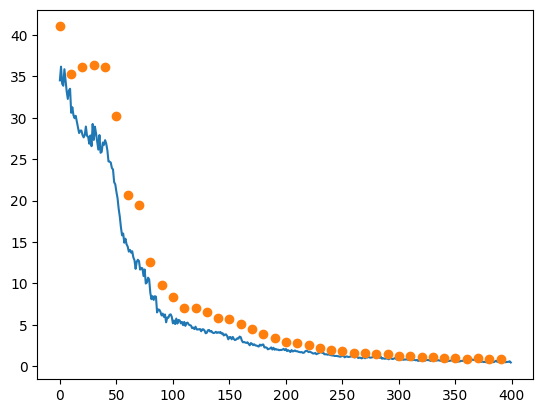

In [12]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(epoch_losses_train)
plt.plot(epoch_losses_val, marker='o')
plt.show()

# Visualize Prediction

In [92]:
# Let's grab a random datum for our dataset
# sample = val_dataset[2]
sample = train_dataset[4]
model.eval()
graph_a = sample[0].to(device)
graph_b = sample[1].to(device)
label   = sample[2].to(device)
with torch.no_grad():
    pred = model(graph_a, graph_b)

pred.to('cpu')

tensor([[-1.6725,  3.7018, -8.3038]])

In [93]:
# Create data to viz the predictions
predicted_graph = graph_b.clone()
predicted_graph.x[:,:3] = predicted_graph.x[:,:3] - pred

true_graph = graph_b.clone()
true_graph.x[:,:3] = true_graph.x[:,:3] - label

In [94]:
# Plat example from training data prediction
import utils.vis
# visualize the original data
utils.vis.plot_3D_graph(graph_a, graph_b)

In [95]:
# Display pairs of data
import utils.vis
utils.vis.plot_3D_graph_subplots([(graph_a, graph_b), (graph_a, predicted_graph), (graph_a, true_graph)], ["Input","Prediction","Truth"])

In [96]:
# Display all data in one plot
utils.vis.plot_many_3D_graphs([graph_a, graph_b, predicted_graph, true_graph], ["Graph A","Graph B (Input)","Graph B (Prediction)", "Graph B (Truth)"])